Volatilidad (Desviación Estándar) de cada activo:
Ticker
INTC    0.036529
MRK     0.016381
MS      0.017924
dtype: float64

El activo más volátil es: INTC (Desviación estándar: 0.0365)


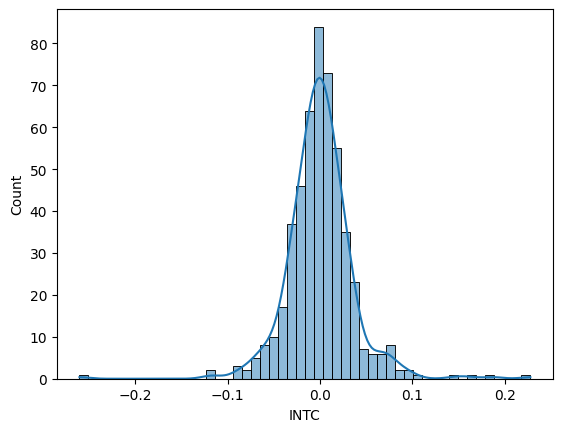

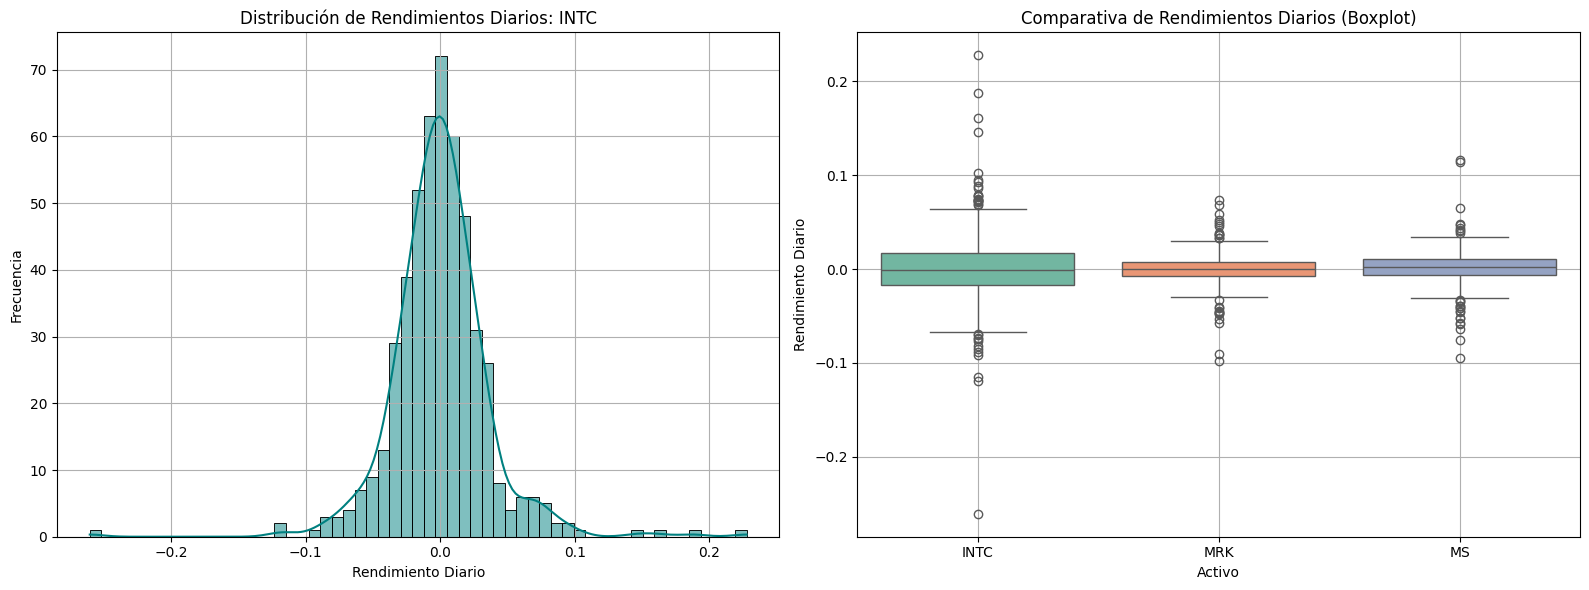

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data=rendimientos, x="INTC", bins=50, kde=True)


# 1. Calcular rendimientos diarios y eliminar nulos
rendimientos = precios_cierre.pct_change().dropna()

# Identificar el activo más volátil (con mayor desviación estándar)
volatilidad = rendimientos.std()
activo_mas_volatil = volatilidad.idxmax()
max_volatilidad = volatilidad.max()

print("Volatilidad (Desviación Estándar) de cada activo:")
print(volatilidad)
print(f"\nEl activo más volátil es: {activo_mas_volatil} (Desviación estándar: {max_volatilidad:.4f})")

# Crear una figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 2. Histograma del activo más volátil
sns.histplot(rendimientos[activo_mas_volatil], kde=True, ax=ax1, color='teal')
ax1.set_title(f"Distribución de Rendimientos Diarios: {activo_mas_volatil}")
ax1.set_xlabel("Rendimiento Diario")
ax1.set_ylabel("Frecuencia")
ax1.grid(True)

# 3. Boxplot comparativo de rendimientos
sns.boxplot(data=rendimientos, ax=ax2, palette="Set2")
ax2.set_title("Comparativa de Rendimientos Diarios (Boxplot)")
ax2.set_xlabel("Activo")
ax2.set_ylabel("Rendimiento Diario")
ax2.grid(True)

plt.tight_layout()
plt.show()

# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [7]:
# Escribe aquí tu código para descargar los datos de tus 3 activos elegidos
!pip install yfinance -q
import yfinance as yf

print("yfinance lista para usar.")
tickers = ["INTC", "MS", "MRK"]
precios = yf.download(tickers, start="2024-01-01", end="2026-01-01", auto_adjust=True, progress=False)
print("Dimensiones de los datos:", precios.shape)
display(precios.head(5))

yfinance lista para usar.
Dimensiones de los datos: (502, 15)


Price           Close                              High              \
Ticker           INTC         MRK         MS       INTC         MRK   
Date                                                                  
2024-01-02  47.168282  104.088913  86.703148  48.727402  104.162450   
2024-01-03  46.428196  105.495270  84.865685  47.178154  106.533957   
2024-01-04  46.250576  107.554268  85.087280  46.536744  108.142548   
2024-01-05  46.270309  107.747284  86.093742  47.197889  107.958693   
2024-01-08  47.809696  107.894363  86.343033  48.115597  108.363152   

Price                        Low                              Open  \
Ticker             MS       INTC         MRK         MS       INTC   
Date                                                                 
2024-01-02  86.933987  46.822909  100.338629  85.198073  48.549781   
2024-01-03  86.056808  46.181500  104.934571  84.274730  46.477534   
2024-01-04  86.001401  44.642120  106.497200  84.634838  45.115776   
2024-01-05  86.730860  46.023613  107.214153  85.004182  46.408459   
2024-01-08  86.638507  46.349256  106.791340  85.207302  46.447933   

Price                                Volume                     
Ticker             MRK         MS      INTC       MRK       MS  
Date                                                            
2024-01-02  100.338629  85.558188  45905700  11920100  6132200  
2024-01-03  105.035675  86.056808  35858400  10721900  7487900  
2024-01-04  106.552349  85.087280  47797800  11492200  8735600  
2024-01-05  107.636979  85.142686  34344000   6861500  6027800  
2024-01-08  108.087392  86.066023  42135100   8193100  6738400

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

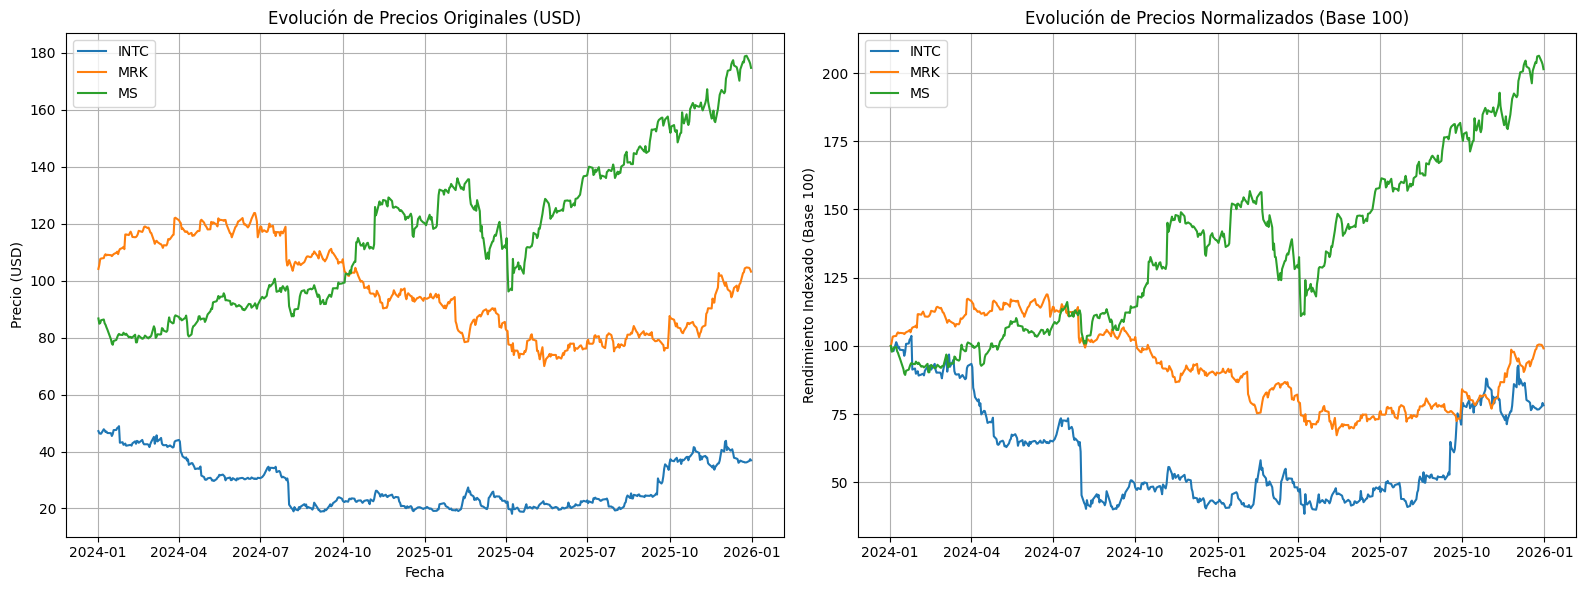

In [9]:
import matplotlib.pyplot as plt

# 1. Extraer los precios de cierre
precios_cierre = precios['Close']

# Crear una figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 2. Graficar precios originales
for ticker in precios_cierre.columns:
    ax1.plot(precios_cierre.index, precios_cierre[ticker], label=ticker)
ax1.set_title("Evolución de Precios Originales (USD)")
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Precio (USD)")
ax1.legend()
ax1.grid(True)

# 3. Normalizar (base 100 en el primer registro) y graficar
# precios_normalizados = (precios_cierre / precios_cierre.iloc[0]) * 100
precios_normalizados = precios_cierre.div(precios_cierre.iloc[0]) * 100

for ticker in precios_normalizados.columns:
    ax2.plot(precios_normalizados.index, precios_normalizados[ticker], label=ticker)
ax2.set_title("Evolución de Precios Normalizados (Base 100)")
ax2.set_xlabel("Fecha")
ax2.set_ylabel("Rendimiento Indexado (Base 100)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**respuesta de interpretación #1:**  
Los activos financieros suelen cotizar a precios nominales muy distintos. Si solo miras el gráfico de precios originales, un cambio de $10 USD parece enorme en el activo barato pero irrelevante en el caro al normalizarlos a base 100 todos parten del mismo punto. valor de 50 significa una pérdida del -50%), independientemente de cuánto costara cada acción individualmente al inicio del periodo.

Volatilidad (Desviación Estándar) de cada activo:
Ticker
INTC    0.036529
MRK     0.016381
MS      0.017924
dtype: float64

El activo más volátil es: INTC (Desviación estándar: 0.0365)


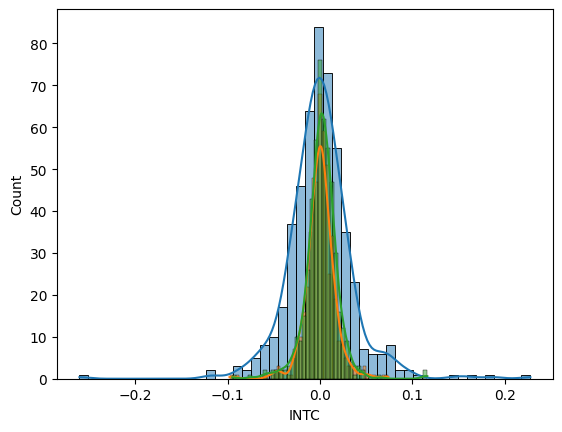

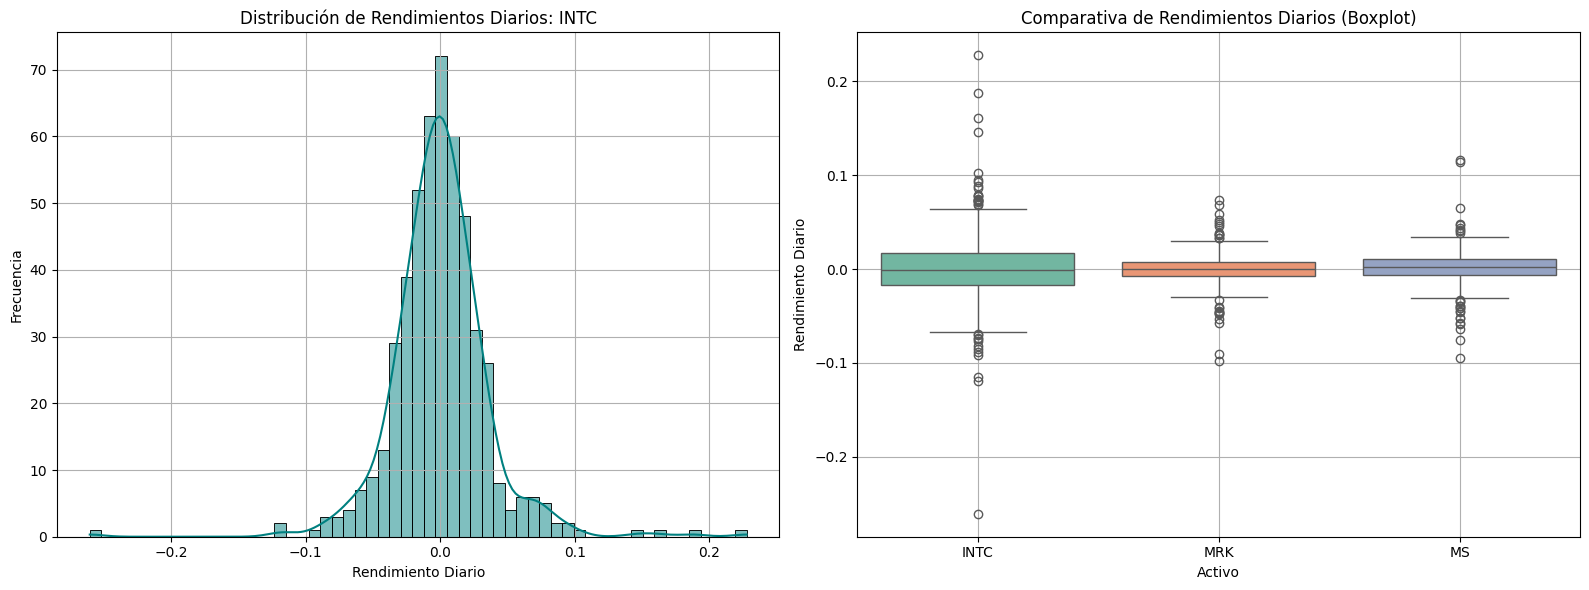

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data=rendimientos, x="INTC", bins=50, kde=True)
sns.histplot(data=rendimientos, x="MRK", bins=50, kde=True)
sns.histplot(data=rendimientos, x="MS", bins=50, kde=True)


# 1. Calcular rendimientos diarios y eliminar nulos
rendimientos = precios_cierre.pct_change().dropna()

# Identificar el activo más volátil (con mayor desviación estándar)
volatilidad = rendimientos.std()
activo_mas_volatil = volatilidad.idxmax()
max_volatilidad = volatilidad.max()

print("Volatilidad (Desviación Estándar) de cada activo:")
print(volatilidad)
print(f"\nEl activo más volátil es: {activo_mas_volatil} (Desviación estándar: {max_volatilidad:.4f})")

# Crear una figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 2. Histograma del activo más volátil
sns.histplot(rendimientos[activo_mas_volatil], kde=True, ax=ax1, color='teal')
ax1.set_title(f"Distribución de Rendimientos Diarios: {activo_mas_volatil}")
ax1.set_xlabel("Rendimiento Diario")
ax1.set_ylabel("Frecuencia")
ax1.grid(True)

# 3. Boxplot comparativo de rendimientos
sns.boxplot(data=rendimientos, ax=ax2, palette="Set2")
ax2.set_title("Comparativa de Rendimientos Diarios (Boxplot)")
ax2.set_xlabel("Activo")
ax2.set_ylabel("Rendimiento Diario")
ax2.grid(True)

plt.tight_layout()
plt.show()

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

- PRIMER: (INTC) es indiscutiblemente el activo que presenta la mayor dispersión. Visualmente, en el Boxplot, muestra la caja más alta y los bigotes más largos. Además, su desviación estándar calculada es de 0.0365.

- SEGUNDO:Sí, se identifican bastantes valores atípicos en los tres activos, representados como puntos individuales que sobresalen de los bigotes del Boxplot (tanto por la parte superior como inferior)

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

Matriz de Correlación de Pearson:


Ticker,INTC,MRK,MS
Ticker,,,
INTC,1.000000,0.099345,0.375765
MRK,0.099345,1.000000,0.085691
MS,0.375765,0.085691,1.000000


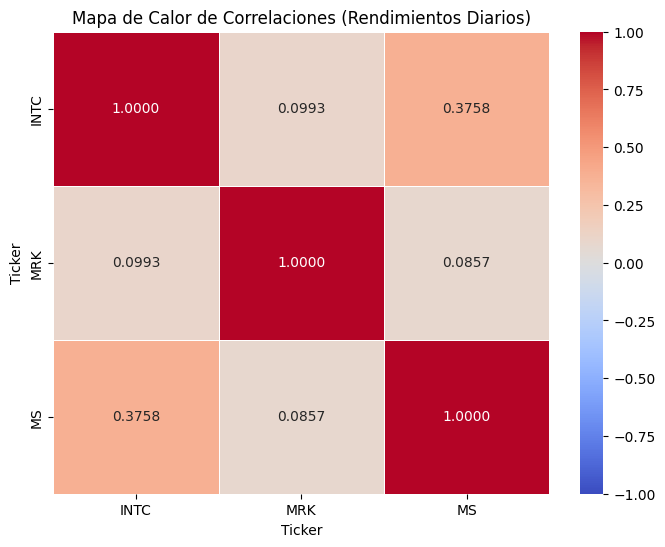

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular matriz de correlación Pearson para los rendimientos de los 3 activos
matriz_correlacion = rendimientos.corr()
print("Matriz de Correlación de Pearson:")
display(matriz_correlacion)

# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".4f"
)
plt.title("Mapa de Calor de Correlaciones (Rendimientos Diarios)")
plt.show()


- PRIMERA: No, no se observa ninguna correlación lineal fuerte entre los activos analizados. La correlación más alta se da entre **Intel (INTC)** y **Morgan Stanley (MS)** con un coeficiente de **0.3758**, que representa una relación positiva débil-moderada.

- SEGUNDO: El par óptimo para maximizar la diversificación es **MRK Y MS** (o en su defecto, MRK e INTC).
  

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [22]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)

In [23]:
# 1. Calcular estadísticas descriptivas clave para los rendimientos diarios
resumen_estadisticas = rendimientos.agg(['mean', 'median', 'std', 'min', 'max'])

# Renombrar los índices para una presentación más clara
resumen_estadisticas = resumen_estadisticas.rename(index={
    'mean': 'Media (Retorno Promedio)',
    'median': 'Mediana',
    'std': 'Desviación Estándar (Volatilidad)',
    'min': 'Mínimo (Peor Día)',
    'max': 'Máximo (Mejor Día)'
})

print("Resumen Estadístico de Rendimientos Diarios (2024-2026):")
display(resumen_estadisticas.round(6))

Resumen Estadístico de Rendimientos Diarios (2024-2026):


Ticker,INTC,MRK,MS
Media (Retorno Promedio),0.000177,0.000116,0.001559
Mediana,-0.000826,0.000129,0.001733
Desviación Estándar (Volatilidad),0.036529,0.016381,0.017924
Mínimo (Peor Día),-0.260585,-0.098059,-0.095078
Máximo (Mejor Día),0.227711,0.073871,0.116119



**Inversionista,**

durante el periodo de **2024 a 2026**, compartimos las siguientes conclusiones clave para el diseño de su estrategia patrimonial:

1. **Perfil de Retorno y Volatilidad (Riesgo):**
   - **Intel (INTC):** Se consolida como el activo de **mayor riesgo y volatilidad** con una desviación estándar diaria del **3.65%**. Asimismo, muestra el comportamiento más extremo con una caída máxima diaria del **-26.05%** (su peor día) y una ganancia máxima del **22.95%**.
      - **(MS):** Presenta un equilibrio sólido con una volatilidad diaria moderada del **1.79%** y un retorno diario promedio ligeramente superior al de sus pares. Es una excelente opción para capturar el crecimiento del sector financiero con un riesgo acotado.
   - **Merck (MRK):** Representa el componente defensivo por excelencia en este análisis, registrando la **menor volatilidad diaria (1.64%)** y un comportamiento muy cercano a su mediana, aportando consistencia y resguardo en momentos de turbulencia.

2. **Estrategia Recomendada de Diversificación (Portafolio Óptimo):**
   - Con base en la matriz de correlación del *Paso 4*, la relación entre **Merck (MRK) y Morgan Stanley (MS)** es sumamente baja (**0.0857**).
   - **Recomendación:** Le sugerimos estructurar un portafolio combinando principalmente **MRK y MS**. Al tener una correlación casi nula, los días de pérdidas en el sector financiero tienden a ser compensados por la estabilidad del sector salud
   - Recomendamos mantener una participación marginal o nula en **INTC** a menos que se busque una exposición táctica y especulativa, debido a su alta volatilidad no correlacionada con incrementos Importantes